In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import litstudy
from collections import Counter
import numpy as np
import requests

In [7]:
MAIN_AUTHORS = [
    'Oleg I. Drivotin',
    'Ivan S. Blekanov',
    'Aleksandra B. Vakaeva',
    'Sergey A. Kostyrko',
    'Mikhail A. Grekov',
    'E. A. Lejnina',
    'Alexander Krylatov',
    'Natalia Kizhaeva',
]

BASE_URL = "https://api.openalex.org"

def get_author_id(display_name):
    url = f"{BASE_URL}/authors"
    params = {'search': display_name, 'select': 'id,display_name'}
    try:
        resp = requests.get(url, params=params)
        if resp.status_code == 200:
            data = resp.json()
            if data['meta']['count'] > 0:
                author = data['results'][0]
                if data['meta']['count'] > 1:
                    print(f"⚠️ Найдено {data['meta']['count']} авторов для {display_name}. Используется первый.")
                print(f"Найден автор: {author['display_name']} (ID: {author['id']})")
                return author['id']
        print(f"Автор {display_name} не найден.")
    except Exception as e:
        print(f"Ошибка при поиске {display_name}: {e}")
    return None

def get_author_works(author_id):
    works = []
    url = f"{BASE_URL}/works"
    params = {'filter': f'author.id:{author_id}', 'per-page': 200}

    while url:
        resp = requests.get(url, params=params)
        data = resp.json()
        works.extend(data['results'])
        url = data.get('next')
        params = None
    return works

def extract_work_info(work):
    primary_loc = work.get('primary_location') or {}
    source = (primary_loc.get('source') or {}).get('display_name', '')

    return {
        'id': work['id'],
        'display_name': work.get('title', ''),
        'authorships.author.display_name': ';'.join(
            a.get('author', {}).get('display_name', '')
            for a in work.get('authorships', []) if a.get('author')
        ),
        'cited_by_count': work.get('cited_by_count', 0),
        'publication_date': work.get('publication_date', ''),
        'primary_location.source.display_name': source,
        'primary_topic.display_name': work.get('primary_topic', {}).get('display_name', '')
    }

all_works_data = {}
author_to_work_ids = {author: set() for author in MAIN_AUTHORS}

for author_name in MAIN_AUTHORS:
    author_id = get_author_id(author_name)
    if not author_id:
        continue

    works_list = get_author_works(author_id)
    for work in works_list:
        wid = work['id']
        if wid not in all_works_data:
            all_works_data[wid] = extract_work_info(work)
        author_to_work_ids[author_name].add(wid)

    print(f"{author_name.split()[-1]}: загружено {len(works_list)} работ")

df_all = pd.DataFrame.from_dict(all_works_data, orient='index').reset_index(drop=True)
print(f"\nВсего уникальных публикаций: {len(df_all)}")

from litstudy.types import Document, DocumentSet, Author

class OpenAlexAuthor(Author):
    def __init__(self, name):
        self._name = name

    @property
    def name(self):
        return self._name

class OpenAlexDocument(Document):
    def __init__(self, entry):
        super().__init__(entry['id'])
        self.entry = entry

    @property
    def title(self):
        return self.entry.get('display_name', 'Unknown Title')

    @property
    def authors(self):
        names_str = self.entry.get('authorships.author.display_name', '')
        if not names_str:
            return []

        names = names_str.split(';')
        return [OpenAlexAuthor(name.strip()) for name in names if name.strip()]

    @property
    def publication_year(self):
        date = self.entry.get('publication_date', '')
        try:
            return int(date[:4]) if date else None
        except:
            return None

documents = [OpenAlexDocument(work) for work in all_works_data.values()]
combined = DocumentSet(documents)
print(f"Успешно создано: {len(combined)} документов")

Найден автор: Oleg I. Drivotin (ID: https://openalex.org/A5087085551)
Drivotin: загружено 31 работ
Найден автор: Ivan S. Blekanov (ID: https://openalex.org/A5067606425)
Blekanov: загружено 76 работ
Найден автор: Aleksandra B. Vakaeva (ID: https://openalex.org/A5012330698)
Vakaeva: загружено 19 работ
Найден автор: Sergey A. Kostyrko (ID: https://openalex.org/A5063936523)
Kostyrko: загружено 34 работ
Найден автор: Mikhail A. Grekov (ID: https://openalex.org/A5000811161)
Grekov: загружено 63 работ
Найден автор: E. A. Lejnina (ID: https://openalex.org/A5052568075)
Lejnina: загружено 1 работ
Найден автор: Alexander Krylatov (ID: https://openalex.org/A5029315125)
Krylatov: загружено 71 работ
Найден автор: Natalia Kizhaeva (ID: https://openalex.org/A5019183428)
Kizhaeva: загружено 7 работ

Всего уникальных публикаций: 265
Успешно создано: 265 документов


In [3]:
G = litstudy.build_coauthor_network(combined)

print(f'Узлов (авторов):    {G.number_of_nodes()}')
print(f'Рёбер (соавторств): {G.number_of_edges()}')
print()

print('Связи соавторства (топ по весу):')
edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
for u, v, d in edges_sorted[:15]:
    name_u = G.nodes[u].get('title', str(u))
    name_v = G.nodes[v].get('title', str(v))
    print(f'  {name_u} — {name_v}  {d['weight']:2d} совм. публ.')

Узлов (авторов):    220
Рёбер (соавторств): 921

Связи соавторства (топ по весу):
  ('Ivan S. Blekanov',) — ('Svetlana S. Bodrunova',)  32 совм. публ.
  ('Victor Zakharov',) — ('Alexander Krylatov',)  21 совм. публ.
  ('Anastasiya Raevskaya',) — ('Alexander Krylatov',)  14 совм. публ.
  ('Dmitri Ovsyannikov',) — ('Oleg I. Drivotin',)  13 совм. публ.
  ('Nikita Tarasov',) — ('Ivan S. Blekanov',)  13 совм. публ.
  ('Sergey A. Kostyrko',) — ('Gleb M. Shuvalov',)  11 совм. публ.
  ('Mikhail A. Grekov',) — ('Sergey A. Kostyrko',)  10 совм. публ.
  ('Tero Tuovinen',) — ('Alexander Krylatov',)  10 совм. публ.
  ('Tero Tuovinen',) — ('Victor Zakharov',)  10 совм. публ.
  ('Alexey Maksimov',) — ('Ivan S. Blekanov',)   9 совм. публ.
  ('Sergey A. Kostyrko',) — ('Mikhail A. Grekov',)   9 совм. публ.
  ('Svetlana S. Bodrunova',) — ('Ivan S. Blekanov',)   8 совм. публ.
  ('Anna Litvinenko',) — ('Svetlana S. Bodrunova',)   8 совм. публ.
  ('Alexander Krylatov',) — ('Victor Zakharov',)   8 совм. публ

In [4]:
litstudy.plot_network(
    G,
    height='600px',
    max_node_size=60,
    min_node_size=10,
    largest_component=False,
    interactive=True,
    gravity=2
)

citation.html


Топ 10 тем (все преподаватели):

 39 Transportation Planning and Optimization
 32 Composite Material Mechanics
 16 Social Media and Politics
 11 Numerical methods in engineering
  8 Elasticity and Wave Propagation
  7 Particle accelerators and beam dynamics
  6 Smart Grid Energy Management
  5 Topic Modeling
  5 Complex Network Analysis Techniques
  4 Smart Agriculture and AI

Топ 3 темы по каждому преподавателю:

  Oleg I. Drivotin
      7  Particle accelerators and beam dynamics
      3  Gas Dynamics and Kinetic Theory
      3  Aerospace Engineering and Control Systems

  Ivan S. Blekanov
     16  Social Media and Politics
      5  Topic Modeling
      5  Complex Network Analysis Techniques

  Aleksandra B. Vakaeva
      9  Composite Material Mechanics
      3  Numerical methods in engineering
      2  Geotechnical and Geomechanical Engineering

  Sergey A. Kostyrko
     18  Composite Material Mechanics
      4  Numerical methods in engineering
      3  Material Properties and Applic

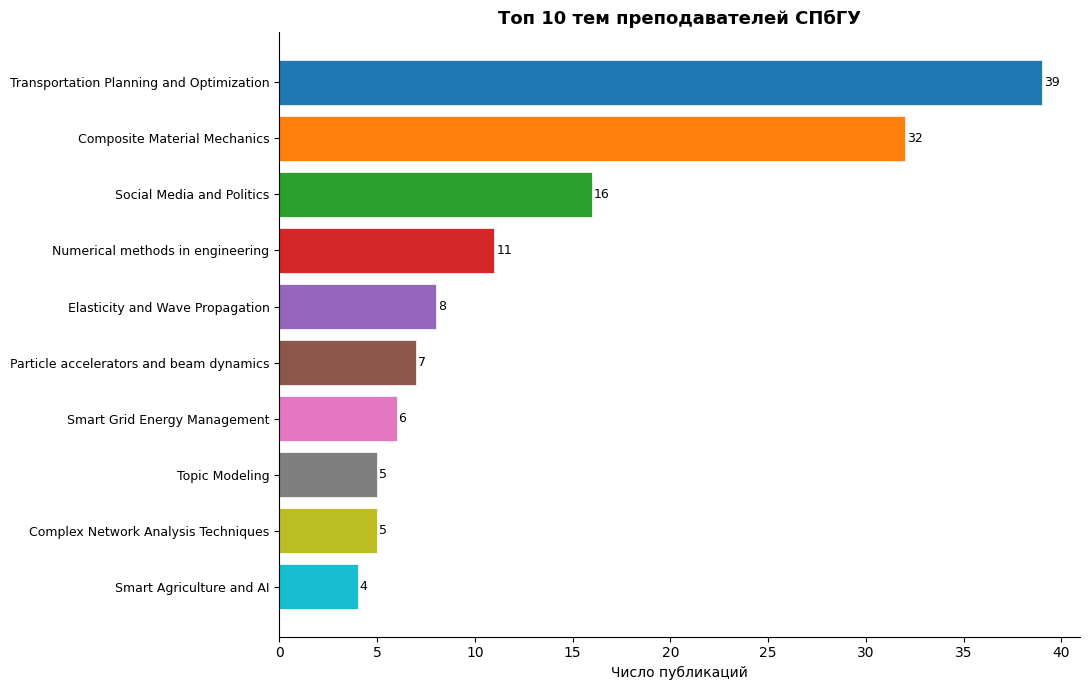

Сохранено: topics_openalex.png


In [8]:
df = df_all.copy()

topic_counts = Counter(df['primary_topic.display_name'].dropna())

print('Топ 10 тем (все преподаватели):\n')
for topic, count in topic_counts.most_common(10):
    print(f'{count:3d} {topic}')

print()

print('Топ 3 темы по каждому преподавателю:')
for author_name, work_ids in author_to_work_ids.items():
    df_author = df[df['id'].isin(work_ids)]
    counts = Counter(df_author['primary_topic.display_name'].dropna())
    top3 = counts.most_common(3)
    print(f'\n  {author_name}')
    for topic, count in top3:
        print(f'    {count:3d}  {topic}')

print()

top10 = topic_counts.most_common(10)
names = [t[0] for t in top10]
vals  = [t[1] for t in top10]

short = [' '.join(n.split()[:5]) + ('...' if len(n.split()) > 5 else '') for n in names]

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.tab10(np.linspace(0, 0.9, len(top10)))
bars = ax.barh(range(len(top10)), vals[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(top10)))
ax.set_yticklabels(short[::-1], fontsize=9)
ax.set_xlabel('Число публикаций', fontsize=10)
ax.set_title(
    'Топ 10 тем преподавателей СПбГУ',
    fontsize=13, fontweight='bold'
)

for i, v in enumerate(vals[::-1]):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('topics_openalex.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: topics_openalex.png')